# Numeric Rank

Investigate the eigenvalues of cosine similarity matrix. Will tell us how many clusters there are.

In [8]:
import pandas as pd
import numpy as np
import pickle
import torch
import tiktoken
import requests
import io
from model import GPTConfig, GPT

In [4]:
num_layers = 7
emb_dim = 384
url = "https://www.dropbox.com/scl/fi/ocaovecmf7che47p1pn0o/ckpt.pt?rlkey=lpfz7b1e5k26ypuw6gltocxub&st=mt9nen3h&dl=1"

In [5]:
def load_model():
    response = requests.get(url, stream=True)
    response.raise_for_status()  # Ensure the request was successful
    checkpoint = torch.load(io.BytesIO(response.content), map_location="cpu")

    # Load the model directly from memory (RAM)
    # ckpt_path = os.path.join('out-tinystories', 'ckpt.pt')
    # checkpoint = torch.load(ckpt_path, map_location=torch.device("cpu"))  # Ensure model loads on CPU
    
    gptconf = GPTConfig(**checkpoint['model_args'])
    model = GPT(gptconf)
    model.to("cpu")  # Move model to CPU
    state_dict = checkpoint['model']

    # Remove unwanted prefixes in state dict
    unwanted_prefix = '_orig_mod.'
    for k in list(state_dict.keys()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)

    model.load_state_dict(state_dict)
    model.eval()  # Set model to evaluation mode
    model.to("cpu")  # Move model to CPU explicitly

    return model

def get_encode_decode():
    enc = tiktoken.get_encoding("gpt2")
    encode = lambda s: enc.encode(s, allowed_special={"<|endoftext|>"})
    decode = lambda l: enc.decode(l)
    return encode, decode


In [9]:
model = load_model()
encode, decode = get_encode_decode()

number of parameters: 29.94M


In [10]:
def get_embeddings(text):
    start_ids = encode(text)
    x = torch.tensor(start_ids, dtype=torch.long, device="cpu")[None, ...]

    embs = model.get_embeddings(x)
    return [emb.detach().cpu().tolist() for emb in embs], [decode([token]) for token in start_ids]

In [11]:
text_prompt = '''
Once upon a time, there was a big octopus. He lived in the deep blue sea. He had a friend, a reliable fish. They played together every day. One day, the octopus and the fish found a big jug. They wanted to pour water on their friends for fun. But they couldn't agree on who would pour the water. The octopus said, "I want to pour the water!" The fish said, "No, I want to pour the water!" They were not happy. Then, the octopus had an idea. He said, "Let's both pour the water!" The fish liked the idea. They picked up the big jug together and poured water on all their friends. Everyone laughed and had fun. The octopus and the fish were happy again. They learned to share and play together. And they lived happily ever after.
'''

In [12]:
all_embs = get_embeddings(text_prompt)

In [15]:
last_layer_embs = all_embs[0][-1]

In [17]:
np.array(last_layer_embs).shape

(178, 384)

In [19]:
import matplotlib.pyplot as plt

In [30]:
def eigen(layer_embs):
    # layer_embs is a n by d array
    
    # ... existing code ...
    import numpy as np
    from sklearn.metrics.pairwise import cosine_similarity
    import matplotlib.pyplot as plt

    # Calculate cosine similarity matrix A
    A = cosine_similarity(layer_embs)

    # Get the eigenvalues of A
    eigenvalues, _ = np.linalg.eig(A)

    # Plot the eigenvalues of A in decreasing magnitude
    plt.figure(figsize=(10, 6))
    plt.plot(np.sort(eigenvalues)[::-1], marker='o')
    plt.title('Eigenvalues in Decreasing Magnitude')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid()
    plt.show()

    # Calculate the numeric rank and print it
    numeric_rank = np.sum(np.abs(eigenvalues)) / np.max(np.abs(eigenvalues))
    print(f'Numeric Rank: {numeric_rank}')
    # ... existing code ...

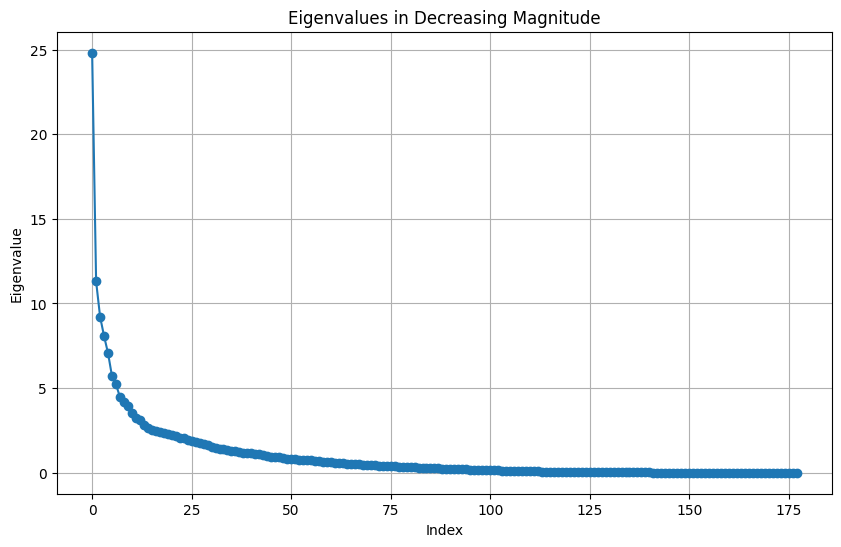

Numeric Rank: 7.174082379020437


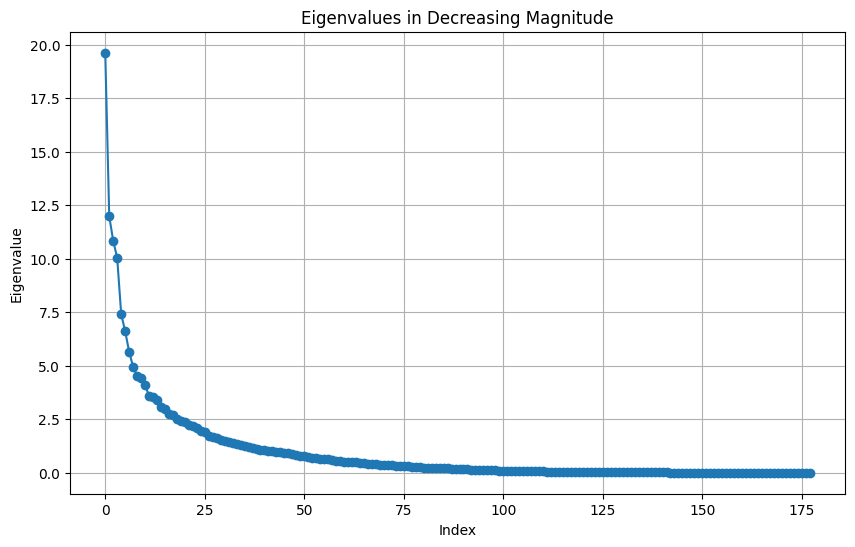

Numeric Rank: 9.07367100401994


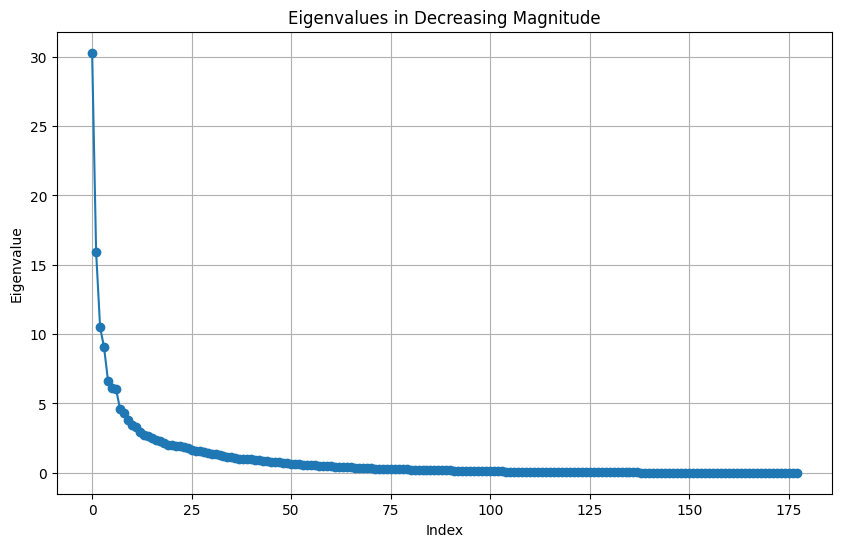

Numeric Rank: 5.875996007934702


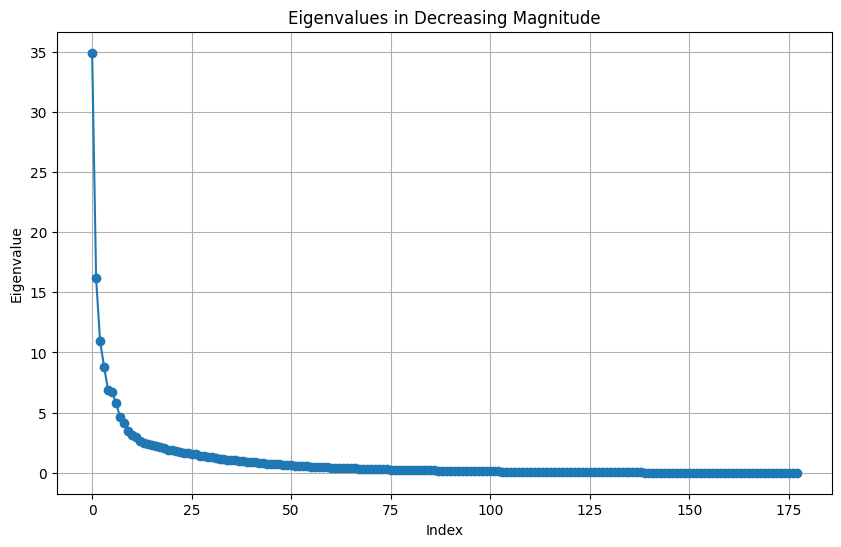

Numeric Rank: 5.098371843453634


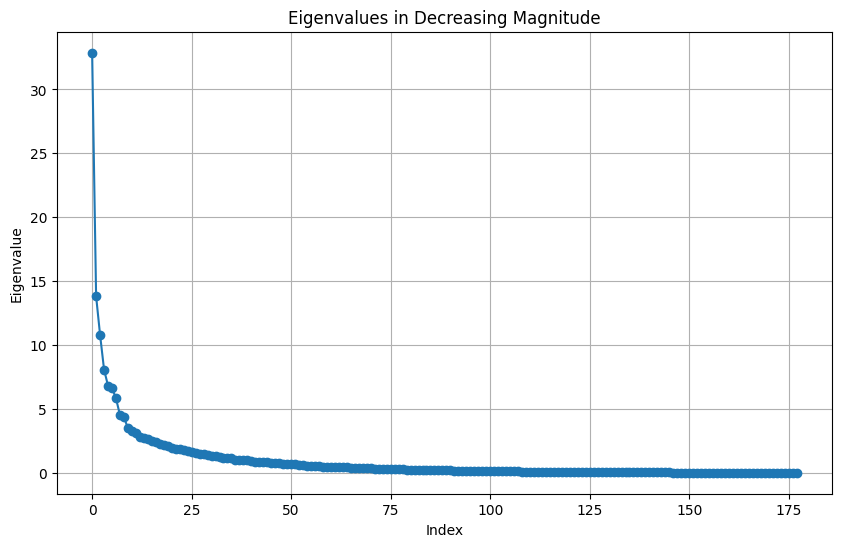

Numeric Rank: 5.414963263215888


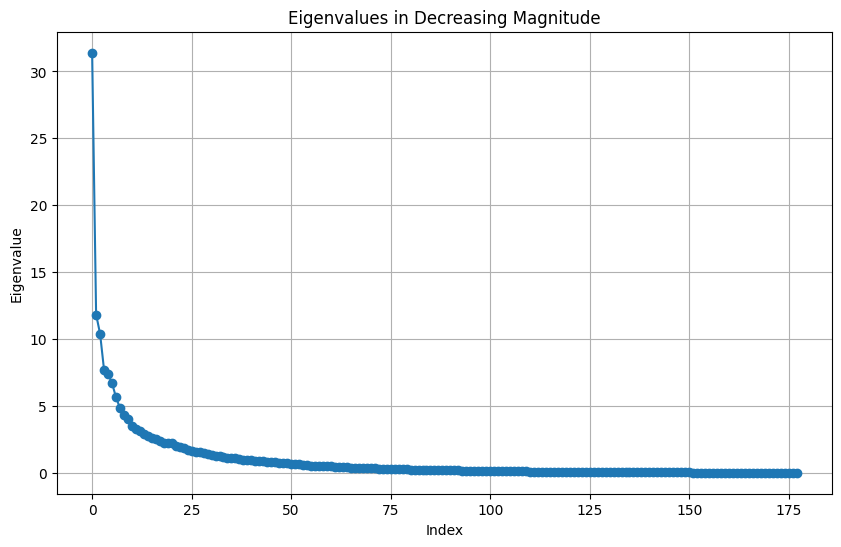

Numeric Rank: 5.668407626132247


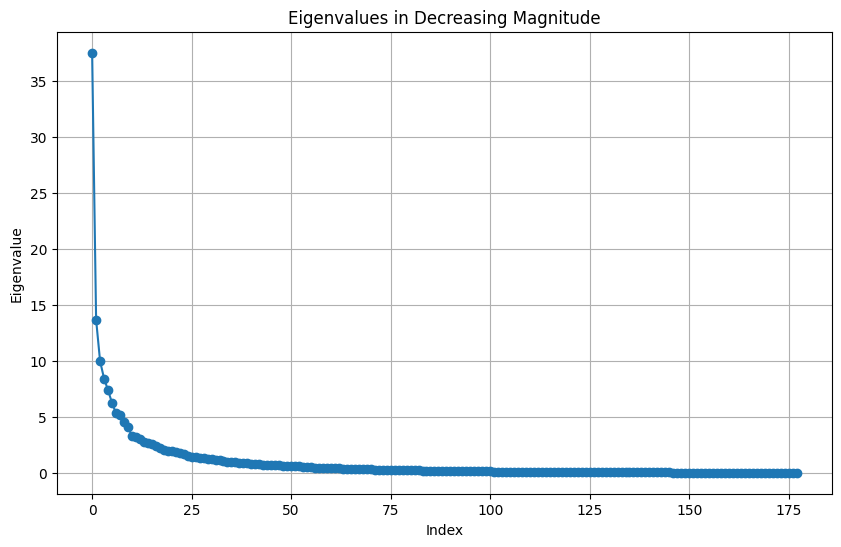

Numeric Rank: 4.747464709600448


In [31]:
for layer_embs in all_embs[0]:
    eigen(layer_embs)